In [1]:
# Install required libraries (run once)
!pip install datasets transformers sentence-transformers rouge-score bert-score nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.1 MB/s eta 0:00:00


In [5]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
from datasets import load_dataset
from transformers import pipeline
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from nltk.tokenize import sent_tokenize

In [4]:
ds = load_dataset(
    "ccdv/arxiv-summarization",
    "document",
    split="test"
)

print(ds[0].keys())
# dict_keys(['article', 'abstract', 'section_names'])

README.md: 0.00B [00:00, ?B/s]

document/train-00000-of-00015.parquet:   0%|          | 0.00/227M [00:00<?, ?B/s]

document/train-00001-of-00015.parquet:   0%|          | 0.00/226M [00:00<?, ?B/s]

document/train-00002-of-00015.parquet:   0%|          | 0.00/226M [00:00<?, ?B/s]

document/train-00003-of-00015.parquet:   0%|          | 0.00/225M [00:00<?, ?B/s]

...

document/test-00000-of-00001.parquet:   0%|          | 0.00/104M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/203037 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6436 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6440 [00:00<?, ? examples/s]

dict_keys(['article', 'abstract'])


In [6]:
def chunk_document(text, max_sentences=5):
    sentences = sent_tokenize(text)
    chunks = []
    for i in range(0, len(sentences), max_sentences):
        chunk = " ".join(sentences[i:i+max_sentences])
        chunks.append(chunk)
    return chunks

In [7]:
embedder = SentenceTransformer("all-MiniLM-L6-v2")

def embed_chunks(chunks):
    return embedder.encode(chunks)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [8]:
def build_interaction_matrix(embeddings):
    return cosine_similarity(embeddings)

In [9]:
def consensus_scores(similarity_matrix):
    # Sum of similarities (excluding self)
    scores = similarity_matrix.sum(axis=1) - 1
    return scores

In [10]:
def dynamic_top_k(num_chunks, min_k=5, max_ratio=0.25):
    """
    Select K as a ratio of total chunks
    """
    k = int(num_chunks * max_ratio)
    return max(min_k, k)

In [11]:
def select_top_k_chunks(chunks, scores):
    k = dynamic_top_k(len(chunks))
    top_indices = np.argsort(scores)[-k:]
    return [chunks[i] for i in sorted(top_indices)]

In [12]:
def extract_sentences(chunks):
    sentences = []
    for chunk in chunks:
        sentences.extend(sent_tokenize(chunk))
    return sentences

In [13]:
def mmr(sentences, lambda_param=0.7, max_sentences=20):
    sent_embeddings = embedder.encode(sentences)
    selected = []
    selected_indices = []

    sim_matrix = cosine_similarity(sent_embeddings)

    scores = sim_matrix.mean(axis=1)

    for _ in range(min(max_sentences, len(sentences))):
        if not selected_indices:
            idx = np.argmax(scores)
        else:
            diversity = np.max(sim_matrix[selected_indices], axis=0)
            mmr_score = lambda_param * scores - (1 - lambda_param) * diversity
            idx = np.argmax(mmr_score)

        selected.append(sentences[idx])
        selected_indices.append(idx)

    return selected

In [13]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

In [14]:
MODEL_NAME = "facebook/bart-large-cnn"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("Summarization device:", device)

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

Summarization device: cuda


In [15]:
def generate_summary(sentences, max_input_tokens=1024):
    """
    Generate summary from filtered sentences
    """

    text = " ".join(sentences)

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_input_tokens
    ).to(device)

    summary_ids = model.generate(
        inputs["input_ids"],
        num_beams=4,
        max_length=200,
        min_length=80,
        length_penalty=2.0,
        early_stopping=True
    )

    summary = tokenizer.decode(
        summary_ids[0],
        skip_special_tokens=True
    )

    return summary

In [18]:
from sentence_transformers import SentenceTransformer
import numpy as np

scs_model = SentenceTransformer("all-mpnet-base-v2")

def semantic_consistency_score(document, summary):
    d = embedder.encode(document, normalize_embeddings=True)
    s = embedder.encode(summary, normalize_embeddings=True)
    return float(np.dot(d, s))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [14]:
def redundancy_score(summary):
    sents = sent_tokenize(summary)
    if len(sents) < 2:
        return 0.0

    emb = embedder.encode(sents, normalize_embeddings=True)
    sim = cosine_similarity(emb)
    return float(sim[np.triu_indices(len(sents), k=1)].mean())

In [15]:
def information_score(scs, redundancy):
    return scs * (1 - redundancy)

In [15]:
from rouge_score import rouge_scorer
rouge_eval = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=True
)

In [16]:
import logging
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()
logging.getLogger("transformers").setLevel(logging.ERROR)

In [40]:
from bert_score import score as bert_score_fn

In [19]:
# ===============================
# SEMANTIC ACCURACY (STABLE)
# ===============================

def semantic_accuracy(summary, reference):
    """
    Embedding-based semantic accuracy
    """
    sum_emb = embedder.encode(summary, normalize_embeddings=True)
    ref_emb = embedder.encode(reference, normalize_embeddings=True)
    return float(np.dot(sum_emb, ref_emb))

**Using SOTA embedder**

In [17]:
import torch
import numpy as np
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from rouge_score import rouge_scorer

In [56]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# 🔥 Strong SOTA embedder
embedder = SentenceTransformer(
    "BAAI/bge-large-en-v1.5",
    device=DEVICE
)

Using device: cuda


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

In [57]:
NUM_SAMPLES = 300
ds_eval = ds.select(range(NUM_SAMPLES))

In [58]:
MODELS = {
    "BART": {
        "name": "facebook/bart-large-cnn",
        "max_input": 1024,
        "max_output": 200
    },
    "LED": {
        "name": "allenai/led-base-16384",
        "max_input": 4096,
        "max_output": 250
    }
}

tokenizers = {}
models = {}

for key, cfg in MODELS.items():
    print(f"Loading {cfg['name']} ...")
    tokenizers[key] = AutoTokenizer.from_pretrained(cfg["name"])
    models[key] = AutoModelForSeq2SeqLM.from_pretrained(cfg["name"]).to(DEVICE)

print("✅ Both summarization models loaded")

Loading facebook/bart-large-cnn ...


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

Loading allenai/led-base-16384 ...


Loading weights:   0%|          | 0/299 [00:00<?, ?it/s]

✅ Both summarization models loaded


In [59]:
rouge_eval = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=True
)

In [60]:
def generate_summary(sentences, model_key):
    text = " ".join(sentences)
    tokenizer = tokenizers[model_key]
    model = models[model_key]

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MODELS[model_key]["max_input"]
    ).to(DEVICE)

    if model_key == "LED":
        global_attention_mask = torch.zeros_like(inputs["input_ids"])
        global_attention_mask[:, 0] = 1

        summary_ids = model.generate(
            inputs["input_ids"],
            global_attention_mask=global_attention_mask,
            num_beams=4,
            max_length=MODELS[model_key]["max_output"],
            min_length=120,
            length_penalty=2.0,
            early_stopping=True
        )
    else:
        summary_ids = model.generate(
            inputs["input_ids"],
            num_beams=4,
            max_length=MODELS[model_key]["max_output"],
            min_length=100,
            length_penalty=2.0,
            early_stopping=True
        )

    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

In [20]:
def embed_text(text):
    return embedder.encode(text, normalize_embeddings=True)

def semantic_accuracy(summary, reference):
    return float(np.dot(embed_text(summary), embed_text(reference)))

def semantic_consistency_score(document, summary):
    return float(np.dot(embed_text(document), embed_text(summary)))

def embed_chunks(chunks):
    return embedder.encode(
        chunks,
        normalize_embeddings=True,
        batch_size=8,
        show_progress_bar=False
    )

In [63]:
def evaluate_model(model_key):
    print(f"\n===== Evaluating {model_key} =====")

    scs_scores, redundancy_scores, info_scores = [], [], []
    semantic_acc_scores = []
    rouge1, rouge2, rougeL = [], [], []

    for sample in tqdm(ds_eval, desc=model_key, total=len(ds_eval)):
        doc = sample["article"]
        gold = sample["abstract"]

        # ----- YOUR PIPELINE -----
        chunks = chunk_document(doc)
        if len(chunks) < 2:
            continue

        embeddings = embed_chunks(chunks)
        sim_matrix = build_interaction_matrix(embeddings)
        scores = consensus_scores(sim_matrix)

        top_chunks = select_top_k_chunks(chunks, scores)
        sentences = extract_sentences(top_chunks)
        final_sents = mmr(sentences)

        if not final_sents:
            continue

        summary = generate_summary(final_sents, model_key)

        # ----- METRICS -----
        scs = semantic_consistency_score(doc, summary)
        red = redundancy_score(summary)
        info = information_score(scs, red)
        sem_acc = semantic_accuracy(summary, gold)

        scs_scores.append(scs)
        redundancy_scores.append(red)
        info_scores.append(info)
        semantic_acc_scores.append(sem_acc)

        r = rouge_eval.score(gold, summary)
        rouge1.append(r["rouge1"].fmeasure)
        rouge2.append(r["rouge2"].fmeasure)
        rougeL.append(r["rougeL"].fmeasure)

    return {
        "Model": model_key,
        "Semantic Accuracy": np.mean(semantic_acc_scores),
        "SCS": np.mean(scs_scores),
        "Redundancy": np.mean(redundancy_scores),
        "Information score": np.mean(info_scores),
        "ROUGE-1": np.mean(rouge1),
        "ROUGE-2": np.mean(rouge2),
        "ROUGE-L": np.mean(rougeL)
    }

In [64]:
results = []

for model_key in MODELS.keys():
    res = evaluate_model(model_key)
    results.append(res)


===== Evaluating BART =====


BART: 100%|██████████| 300/300 [29:22<00:00,  5.87s/it]



===== Evaluating LED =====


LED: 100%|██████████| 300/300 [30:34<00:00,  6.12s/it]


In [65]:
import pandas as pd

df_results = pd.DataFrame(results)
display(df_results)

,Model,Semantic Accuracy,SCS,Redundancy,Information score,ROUGE-1,ROUGE-2,ROUGE-L
0,BART,0.842387,0.827664,0.622786,0.311913,0.355647,0.104063,0.193153
1,LED,0.838826,0.835076,0.639245,0.297606,0.366930,0.099767,0.179829



**BGE-large → for Semantic Accuracy & SCS   E5-large → for MMR & redundancy control**


In [21]:
def mmr(sentences, lambda_param=0.75, max_sentences=15):
    if len(sentences) == 0:
        return []

    emb = mmr_embedder.encode(
        sentences,
        normalize_embeddings=True
    )
    sim = cosine_similarity(emb)
    scores = sim.mean(axis=1)

    selected, selected_idx = [], []

    for _ in range(min(max_sentences, len(sentences))):
        if not selected_idx:
            idx = np.argmax(scores)
        else:
            diversity = np.max(sim[selected_idx], axis=0)
            mmr_score = lambda_param * scores - (1 - lambda_param) * diversity
            idx = np.argmax(mmr_score)

        selected.append(sentences[idx])
        selected_idx.append(idx)

    return selected

In [19]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from rouge_score import rouge_scorer

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ds_eval = ds.select(range(300))

semantic_embedder = SentenceTransformer("BAAI/bge-large-en-v1.5", device=DEVICE)
mmr_embedder = SentenceTransformer("intfloat/e5-large-v2", device=DEVICE)

MODELS = {
    "BART": {"name": "facebook/bart-large-cnn", "max_input": 1024, "max_output": 200},
    "LED": {"name": "allenai/led-base-16384", "max_input": 4096, "max_output": 250}
}

tokenizers, models = {}, {}
for key, cfg in MODELS.items():
    tokenizers[key] = AutoTokenizer.from_pretrained(cfg["name"])
    models[key] = AutoModelForSeq2SeqLM.from_pretrained(cfg["name"]).to(DEVICE)

rouge_eval = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

def generate_summary(final_sents, model_key):
    tokenizer = tokenizers[model_key]
    model = models[model_key]
    text = " ".join(final_sents)
    inputs = tokenizer(text, return_tensors="pt", truncation=True,
                       max_length=MODELS[model_key]["max_input"]).to(DEVICE)
    if model_key == "LED":
        global_attention_mask = torch.zeros_like(inputs["input_ids"])
        global_attention_mask[:, 0] = 1
        output_ids = model.generate(
            inputs["input_ids"],
            global_attention_mask=global_attention_mask,
            num_beams=4,
            max_length=MODELS[model_key]["max_output"],
            min_length=120,
            length_penalty=2.0,
            early_stopping=True
        )
    else:
        output_ids = model.generate(
            inputs["input_ids"],
            num_beams=4,
            max_length=MODELS[model_key]["max_output"],
            min_length=100,
            length_penalty=2.0,
            early_stopping=True
        )
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

def semantic_accuracy(summary, reference):
    s = semantic_embedder.encode(summary, normalize_embeddings=True)
    r = semantic_embedder.encode(reference, normalize_embeddings=True)
    return float(np.dot(s, r))

results = []

for model_key in MODELS.keys():
    scs_scores, red_scores, info_scores = [], [], []
    sem_acc_scores = []
    rouge1, rouge2, rougeL = [], [], []

    for sample in tqdm(ds_eval, desc=model_key, total=len(ds_eval)):
        doc = sample["article"]
        gold = sample["abstract"]

        chunks = chunk_document(doc)
        embeddings = embed_chunks(chunks)
        sim_matrix = build_interaction_matrix(embeddings)
        scores = consensus_scores(sim_matrix)
        top_chunks = select_top_k_chunks(chunks, scores)
        sentences = extract_sentences(top_chunks)
        final_sents = mmr(sentences)

        if not final_sents:
            continue

        summary = generate_summary(final_sents, model_key)

        scs = semantic_consistency_score(doc, summary)
        red = redundancy_score(summary)
        info = information_score(scs, red)
        sem_acc = semantic_accuracy(summary, gold)

        scs_scores.append(scs)
        red_scores.append(red)
        info_scores.append(info)
        sem_acc_scores.append(sem_acc)

        r = rouge_eval.score(gold, summary)
        rouge1.append(r["rouge1"].fmeasure)
        rouge2.append(r["rouge2"].fmeasure)
        rougeL.append(r["rougeL"].fmeasure)

    results.append({
        "Model": model_key,
        "Semantic Accuracy": np.mean(sem_acc_scores),
        "SCS": np.mean(scs_scores),
        "Redundancy": np.mean(red_scores),
        "Information Score": np.mean(info_scores),
        "ROUGE-1": np.mean(rouge1),
        "ROUGE-2": np.mean(rouge2),
        "ROUGE-L": np.mean(rougeL)
    })

df_results = pd.DataFrame(results)
display(df_results)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/648M [00:00<?, ?B/s]

KeyboardInterrupt: 

In [23]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from rouge_score import rouge_scorer
from difflib import SequenceMatcher

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# evaluate on 300 samples
ds_eval = ds.select(range(300))

# Embedding models
semantic_embedder = SentenceTransformer("BAAI/bge-large-en-v1.5", device=DEVICE)
mmr_embedder = SentenceTransformer("intfloat/e5-large-v2", device=DEVICE)

# Summarization models
MODELS = {
    "BART": {"name": "facebook/bart-large-cnn", "max_input": 1024, "max_output": 200},
    "LED": {"name": "allenai/led-base-16384", "max_input": 4096, "max_output": 250}
}

tokenizers, models = {}, {}

for key, cfg in MODELS.items():
    tokenizers[key] = AutoTokenizer.from_pretrained(cfg["name"])
    models[key] = AutoModelForSeq2SeqLM.from_pretrained(cfg["name"]).to(DEVICE)

# ROUGE
rouge_eval = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=True
)

# -----------------------------
# Generate Summary
# -----------------------------
def generate_summary(final_sents, model_key):

    tokenizer = tokenizers[model_key]
    model = models[model_key]

    text = " ".join(final_sents)

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MODELS[model_key]["max_input"]
    ).to(DEVICE)

    if model_key == "LED":

        global_attention_mask = torch.zeros_like(inputs["input_ids"])
        global_attention_mask[:, 0] = 1

        output_ids = model.generate(
            inputs["input_ids"],
            global_attention_mask=global_attention_mask,
            num_beams=4,
            max_length=MODELS[model_key]["max_output"],
            min_length=120,
            length_penalty=2.0,
            early_stopping=True
        )

    else:

        output_ids = model.generate(
            inputs["input_ids"],
            num_beams=4,
            max_length=MODELS[model_key]["max_output"],
            min_length=100,
            length_penalty=2.0,
            early_stopping=True
        )

    return tokenizer.decode(output_ids[0], skip_special_tokens=True)


# -----------------------------
# Semantic Accuracy
# -----------------------------
def semantic_accuracy(summary, reference):

    s = semantic_embedder.encode(summary, normalize_embeddings=True)
    r = semantic_embedder.encode(reference, normalize_embeddings=True)

    return float(np.dot(s, r))


# -----------------------------
# Layout Fidelity Index (LFI)
# -----------------------------
def layout_fidelity_index(doc, summary):

    doc_sents = doc.split(". ")
    sum_sents = summary.split(". ")

    matches = 0

    for s in sum_sents:

        best = max([SequenceMatcher(None, s, d).ratio() for d in doc_sents])

        if best > 0.6:
            matches += 1

    if len(sum_sents) == 0:
        return 0

    return matches / len(sum_sents)


# -----------------------------
# Instruction Adherence Rate (IAR)
# -----------------------------
def instruction_adherence_rate(summary, reference):

    emb_sum = semantic_embedder.encode(summary, normalize_embeddings=True)
    emb_ref = semantic_embedder.encode(reference, normalize_embeddings=True)

    similarity = float(np.dot(emb_sum, emb_ref))

    return similarity


# -----------------------------
# Evaluation Loop
# -----------------------------

results = []

total_steps = len(ds_eval) * len(MODELS)

with tqdm(total=total_steps, desc="Running Models", leave=True) as pbar:

    for model_key in MODELS.keys():

        scs_scores = []
        red_scores = []
        info_scores = []
        sem_acc_scores = []

        rouge1 = []
        rouge2 = []
        rougeL = []

        lfi_scores = []
        iar_scores = []

        for sample in ds_eval:

            doc = sample["article"]
            gold = sample["abstract"]

            # YOUR PIPELINE
            chunks = chunk_document(doc)
            embeddings = embed_chunks(chunks)
            sim_matrix = build_interaction_matrix(embeddings)
            scores = consensus_scores(sim_matrix)
            top_chunks = select_top_k_chunks(chunks, scores)
            sentences = extract_sentences(top_chunks)
            final_sents = mmr(sentences)

            if not final_sents:
                pbar.update(1)
                continue

            summary = generate_summary(final_sents, model_key)

            scs = semantic_consistency_score(doc, summary)
            red = redundancy_score(summary)
            info = information_score(scs, red)

            sem_acc = semantic_accuracy(summary, gold)
            lfi = layout_fidelity_index(doc, summary)
            iar = instruction_adherence_rate(summary, gold)

            scs_scores.append(scs)
            red_scores.append(red)
            info_scores.append(info)
            sem_acc_scores.append(sem_acc)

            lfi_scores.append(lfi)
            iar_scores.append(iar)

            r = rouge_eval.score(gold, summary)

            rouge1.append(r["rouge1"].fmeasure)
            rouge2.append(r["rouge2"].fmeasure)
            rougeL.append(r["rougeL"].fmeasure)

            pbar.update(1)

        results.append({
            "Model": model_key,
            "Semantic Accuracy": np.mean(sem_acc_scores),
            "SCS": np.mean(scs_scores),
            "Redundancy": np.mean(red_scores),
            "Information Score": np.mean(info_scores),
            "Layout Fidelity Index": np.mean(lfi_scores),
            "Instruction Adherence Rate": np.mean(iar_scores),
            "ROUGE-1": np.mean(rouge1),
            "ROUGE-2": np.mean(rouge2),
            "ROUGE-L": np.mean(rougeL)
        })

df_results = pd.DataFrame(results)

display(df_results)


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/e5-large-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/299 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie led.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie led.shared.weight to led.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie led.shared.weight to led.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Running Models: 100%|██████████| 600/600 [41:58<00:00,  4.20s/it]


,Model,Semantic Accuracy,SCS,Redundancy,Information Score,Layout Fidelity Index,Instruction Adherence Rate,ROUGE-1,ROUGE-2,ROUGE-L
0,BART,0.841795,0.570655,0.368258,0.358551,0.82658,0.841795,0.352082,0.103075,0.193566
1,LED,0.851747,0.620082,0.393342,0.375003,0.93795,0.851747,0.386700,0.110932,0.190708


In [17]:
def compute_semantic_accuracy(summary, reference):
    s = semantic_embedder.encode(summary, normalize_embeddings=True)
    r = semantic_embedder.encode(reference, normalize_embeddings=True)
    return float(np.dot(s, r))

Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/299 [00:00<?, ?it/s]

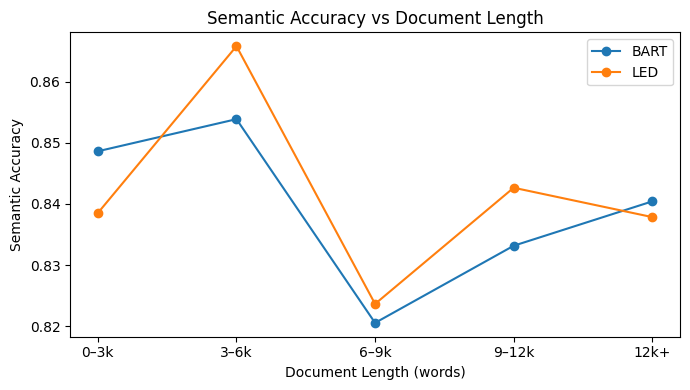

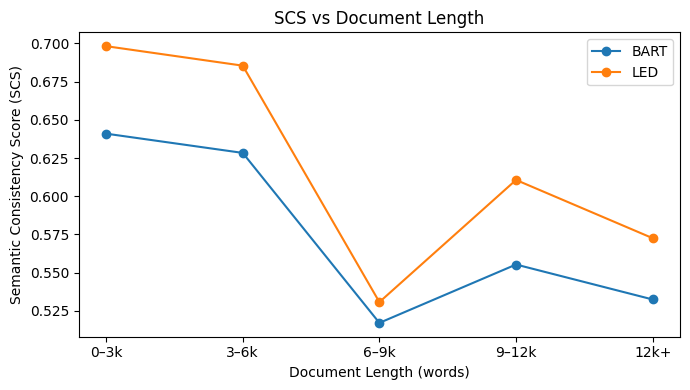

In [33]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODELS = {
    "BART": {"name": "facebook/bart-large-cnn", "max_input": 1024, "max_output": 200},
    "LED": {"name": "allenai/led-base-16384", "max_input": 4096, "max_output": 250}
}

tokenizer_store, model_store = {}, {}
for key, cfg in MODELS.items():
    tokenizer_store[key] = AutoTokenizer.from_pretrained(cfg["name"])
    model_store[key] = AutoModelForSeq2SeqLM.from_pretrained(cfg["name"]).to(DEVICE)

def generate_summary(final_sents, model_key):
    tokenizer = tokenizer_store[model_key]
    model = model_store[model_key]
    text = " ".join(final_sents)

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MODELS[model_key]["max_input"]
    ).to(DEVICE)

    if model_key == "LED":
        global_attention_mask = torch.zeros_like(inputs["input_ids"])
        global_attention_mask[:, 0] = 1
        ids = model.generate(
            inputs["input_ids"],
            global_attention_mask=global_attention_mask,
            num_beams=4,
            max_length=MODELS[model_key]["max_output"],
            min_length=120,
            length_penalty=2.0
        )
    else:
        ids = model.generate(
            inputs["input_ids"],
            num_beams=4,
            max_length=MODELS[model_key]["max_output"],
            min_length=100,
            length_penalty=2.0
        )

    return tokenizer.decode(ids[0], skip_special_tokens=True)

length_bins = [(0,3000),(3000,6000),(6000,9000),(9000,12000),(12000,20000)]
bin_labels = ["0–3k","3–6k","6–9k","9–12k","12k+"]

length_groups = {i: [] for i in range(len(length_bins))}
for sample in ds:
    doc_len = len(sample["article"].split())
    for i, (low, high) in enumerate(length_bins):
        if low <= doc_len < high:
            length_groups[i].append(sample)

results = {
    "BART": {"semantic": [], "scs": []},
    "LED": {"semantic": [], "scs": []}
}

model_names = ["BART", "LED"]

for model_key in model_names:
    for bin_idx in range(len(length_bins)):
        sem_vals, scs_vals = [], []

        for sample in tqdm(length_groups[bin_idx][:15], leave=False):
            doc = sample["article"]
            gold = sample["abstract"]

            chunks = chunk_document(doc)
            embeddings = embed_chunks(chunks)
            sim_matrix = build_interaction_matrix(embeddings)
            scores = consensus_scores(sim_matrix)
            top_chunks = select_top_k_chunks(chunks, scores)
            sentences = extract_sentences(top_chunks)
            final_sents = mmr(sentences)

            if not final_sents:
                continue

            summary = generate_summary(final_sents, model_key)

            sem_vals.append(compute_semantic_accuracy(summary, gold))
            scs_vals.append(semantic_consistency_score(doc, summary))

        results[model_key]["semantic"].append(np.mean(sem_vals))
        results[model_key]["scs"].append(np.mean(scs_vals))

plt.figure(figsize=(7,4))
plt.plot(bin_labels, results["BART"]["semantic"], marker="o", label="BART")
plt.plot(bin_labels, results["LED"]["semantic"], marker="o", label="LED")
plt.xlabel("Document Length (words)")
plt.ylabel("Semantic Accuracy")
plt.title("Semantic Accuracy vs Document Length")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(bin_labels, results["BART"]["scs"], marker="o", label="BART")
plt.plot(bin_labels, results["LED"]["scs"], marker="o", label="LED")
plt.xlabel("Document Length (words)")
plt.ylabel("Semantic Consistency Score (SCS)")
plt.title("SCS vs Document Length")
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
!pip install PyPDF2

In [49]:
def generate_summary(final_sents, model_key):
    tokenizer = tokenizer_store[model_key]
    model = model_store[model_key]
    text = " ".join(final_sents)

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MODELS[model_key]["max_input"]
    ).to(DEVICE)

    if model_key == "LED":
        global_attention_mask = torch.zeros_like(inputs["input_ids"])
        global_attention_mask[:, 0] = 1

        output_ids = model.generate(
            inputs["input_ids"],
            global_attention_mask=global_attention_mask,
            num_beams=4,
            do_sample=False,
            max_length=350,          # 🔼 longer summary
            min_length=180,
            length_penalty=1.2,
            repetition_penalty=2.0,  # 🔴 key fix
            no_repeat_ngram_size=4,  # 🔴 key fix
            early_stopping=True
        )
    else:
        output_ids = model.generate(
            inputs["input_ids"],
            num_beams=4,
            do_sample=False,
            max_length=250,
            min_length=120,
            length_penalty=1.0,
            repetition_penalty=1.5,
            no_repeat_ngram_size=3,
            early_stopping=True
        )

    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

In [54]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from rouge_score import rouge_scorer

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


semantic_embedder = SentenceTransformer("BAAI/bge-large-en-v1.5", device=DEVICE)
mmr_embedder = SentenceTransformer("intfloat/e5-large-v2", device=DEVICE)

MODELS = {
    "BART": {"name": "facebook/bart-large-cnn", "max_input": 1024, "max_output": 200},
    "LED": {"name": "allenai/led-base-16384", "max_input": 4096, "max_output": 250}
}



Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/e5-large-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [55]:
tokenizer_store, model_store = {}, {}
for key, cfg in MODELS.items():
    tokenizer_store[key] = AutoTokenizer.from_pretrained(cfg["name"])
    model_store[key] = AutoModelForSeq2SeqLM.from_pretrained(cfg["name"]).to(DEVICE)

Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/299 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie led.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie led.shared.weight to led.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie led.shared.weight to led.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [56]:
from PyPDF2 import PdfReader

def read_pdf(pdf_path):
    reader = PdfReader(pdf_path)
    text = ""
    for page in reader.pages:
        page_text = page.extract_text()
        if page_text:
            text += page_text + " "
    return text.strip()

pdf_path = "/kaggle/input/datasets/poojithagatta/test-documents/GMMDC-Media-Articles-2019.pdf"  # change after upload
document = read_pdf(pdf_path)

models_to_test = ["BART", "LED"]

for model_key in models_to_test:
    chunks = chunk_document(document)
    embeddings = embed_chunks(chunks)
    sim_matrix = build_interaction_matrix(embeddings)
    scores = consensus_scores(sim_matrix)
    top_chunks = select_top_k_chunks(chunks, scores)
    sentences = extract_sentences(top_chunks)
    final_sents = mmr(sentences)

    summary = generate_summary(final_sents, model_key)

    print(f"\n===== {model_key} SUMMARY =====\n")
    print(summary)

Input ids are automatically padded from 26 to 1024 to be a multiple of `config.attention_window`: 1024



===== BART SUMMARY =====

Newspaper Articles  2019. Article Link: 2019 Newspaper Articles. Newspapers will be published every day this year. See www.dailymail.co.uk for more details on how to get your hands on a copy of next month's newspapers. For more, go to www.dailytimes.com/newspapers. In the U.S., see The Daily Mail’s Newsquiz, which tests readers’ knowledge of stories and events in the news. To test your knowledge of articles, send a photo of your own to jennifer.smith@mailonline.com.

===== LED SUMMARY =====

Newspaper Articles  2019 Newspaper Articles  2018Article Link Newspaper Articles  2019 News Articles  2019News Articles  2019Article Link Newspaper Article  2019 Newspaper articles  2019advertisementArticle Link Newspapers Articles  2019©2019 The New York Times. All rights reservedAbout the Author: James E. Smith Jr. and Associates, Inc. , CEO & Editor-in-Chief of National Newspaper Publishers Association (NNPA)Philadelphia EaglesSportsNewspaper Topics  2019Sportnewspaper

In [59]:
from nltk.tokenize import sent_tokenize

def clean_incomplete_sentences(text):

    sentences = sent_tokenize(text)

    cleaned = []

    for s in sentences:
        s = s.strip()

        if len(s.split()) < 5:
            continue

        if not s.endswith((".", "!", "?")):
            continue

        cleaned.append(s)

    return " ".join(cleaned)

In [63]:
from PyPDF2 import PdfReader
from nltk.tokenize import sent_tokenize
from sklearn.metrics.pairwise import cosine_similarity

def read_pdf(pdf_path):
    reader = PdfReader(pdf_path)
    text = ""
    for page in reader.pages:
        page_text = page.extract_text()
        if page_text:
            text += page_text + " "
    return text.strip()

pdf_path = "/kaggle/input/datasets/poojithagatta/test-documents/Ad-PDF.pdf"
document = read_pdf(pdf_path)

chunks = chunk_document(document)
embeddings = embed_chunks(chunks)
sim_matrix = build_interaction_matrix(embeddings)
scores = consensus_scores(sim_matrix)
top_chunks = select_top_k_chunks(chunks, scores)
sentences = extract_sentences(top_chunks)
final_sents = mmr(sentences)

bart_summary = generate_summary(final_sents, "BART")
led_summary = generate_summary(final_sents, "LED")

combined_summary = bart_summary + " " + led_summary

def remove_duplicate_sentences(text, threshold=0.85):
    sentences = sent_tokenize(text)
    embeddings = semantic_embedder.encode(sentences, normalize_embeddings=True)
    unique_sentences = []
    for i, sent in enumerate(sentences):
        if not unique_sentences:
            unique_sentences.append(sent)
            continue
        sims = cosine_similarity(
            [embeddings[i]],
            semantic_embedder.encode(unique_sentences, normalize_embeddings=True)
        )[0]
        if max(sims) < threshold:
            unique_sentences.append(sent)
    return " ".join(unique_sentences)

final_summary = remove_duplicate_sentences(combined_summary)
final_summary = clean_incomplete_sentences(final_summary)

print(final_summary)


Advertisers and marketers use ads to introduce a brand or an views of specific products and services. Banner ads are one of the most popular online advertising tools to date. A good advertisement contains compelling high-resolution images, an effective headline, well-written content, and a call to action statement. Nowadays, marketing groups focus on the value of both digital and print autoimmuneads. How to Design an Ad? Read on to find out how to create an effective ad campaign for your company or business. Back to Mail Online home. Back To the page you came from. Click here for more information. Develop enticing and colorful digital advertisements that get theaudience’s attention and interest. Job AdvertisementsCompanies that need to fill specific roles and positions must have strongjob adsavailable indifferent locations, including TV and video content on apps like Facebook, Youtube, andInstagram. Magazine AdvertisementsPublishers and editors are meticulous about the content that goe